# Sentinel-2 image and rasters processing notebook

**Description**

This notebook is used for processing Sentinel-2 images including calculating indices and stack all rasters together. The stacked image is used as an input of deep learning model in later step.

Main steps of Sentinel-2 image and rasters processing:
1. Import data
2. Calculate indices (NDVI, NDWI, and NDBI)
3. Stack Sentinel-2 image, PUGS binary mask, and PUGS SDT raster together

*PUGS = public urban green space, SDT = signed-distance transform*

**Input files**
3 raster files
- sentinel2_openeo_med_4months_dresden.geotiff
- public_green_spaces_dresden.geotiff
- sdt_public_green_spaces_dresden.geotiff

**Output files**

1 geotiff file
- stacked_sentinel2_dresden.geotiff

**Requirements/Dependencies**

This notebook requires user to run *1_data_acquisition_satellite_image.ipynb*, *1_data_acquisition_osm.ipynb*, and *2_data_processing_osm.ipynb* first.

# Import libraries

In [54]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root_dir)

In [55]:
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
from pugs_detection.utils import contrast_stretch, normalize_sdt_minmax

# Import Sentinel-2 image

In [56]:
file_path = '../data/raw/sentinel-2/sentinel2_openeo_med_4months_dresden.geotiff'
data = rioxarray.open_rasterio(file_path, masked=True)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

## Explore value

In [57]:
data.isel(band=1).min()

<xarray.DataArray ()> Size: 4B
array(-415., dtype=float32)
Coordinates:
    band         int64 8B 2
    spatial_ref  int64 8B 0

In [58]:
import numpy as np

data_new = np.where(data < 0, 0, data)

In [59]:
data_new_norm = data_new/10000

In [60]:
data_new_norm_xarray = data.copy()
data_new_norm_xarray.data = data_new_norm

In [61]:
print(data_new_norm_xarray.min())
print(data_new_norm_xarray.max())

<xarray.DataArray ()> Size: 4B
array(0., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 4B
array(1.7512, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0


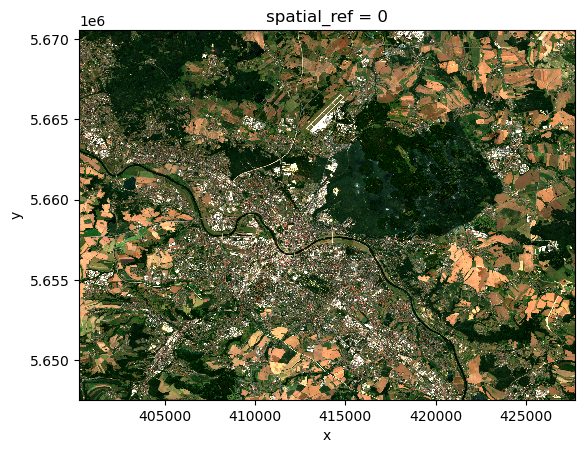

In [62]:
data_new_norm_xarray.sel(band=[4, 3, 2]).plot.imshow(robust=True)

## Normalize Sentinel-2 image values to [0,1] range
Min and max normalization give the worst result according to https://medium.com/sentinel-hub/how-to-normalize-satellite-images-for-deep-learning-d5b668c885af

In [63]:
processed_sat_img = contrast_stretch(data)

In [64]:
processed_sat_img.min()

<xarray.DataArray ()> Size: 4B
array(0., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0

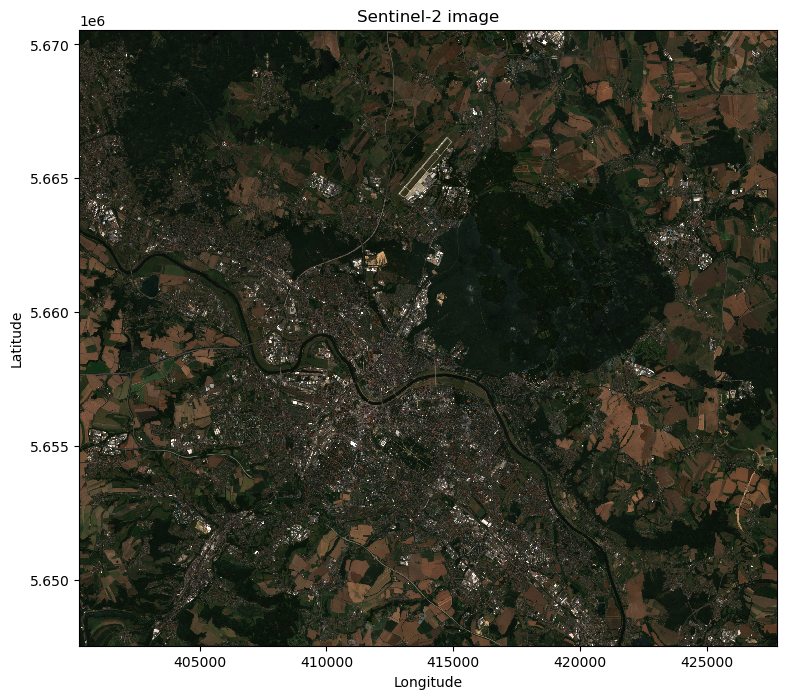

In [65]:
# Plot the raster data
plt.figure(figsize=(9,8))
processed_sat_img.sel(band=[4, 3, 2]).plot.imshow()
plt.title("Sentinel-2 image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Import binary mask

In [66]:
file_path = '../data/processed/osm/public_green_spaces_dresden.geotiff'
binary_mask_pugs = rioxarray.open_rasterio(file_path)

In [67]:
binary_mask_pugs = binary_mask_pugs.assign_coords(band=[14])
binary_mask_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 6MB
[6320847 values with dtype=uint8]
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 14
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

# Import SDT raster

In [68]:
file_path = '../data/processed/osm/sdt_public_green_spaces_dresden.geotiff'
sdt_pugs = rioxarray.open_rasterio(file_path)

In [69]:
sdt_pugs = sdt_pugs.assign_coords(band=[15])
sdt_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 51MB
[6320847 values with dtype=float64]
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 15
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

## Normalize SDT values to [-1,1] range

In [70]:
# Check the range of your SDT values
print("SDT min:", sdt_pugs.min().values, ", SDT max:", sdt_pugs.max().values)

normalized_sdt_pugs = sdt_pugs.copy()
# Apply normalization
normalized_sdt_pugs.values = normalize_sdt_minmax(sdt_pugs.values)

SDT min: -252.20031720836514 , SDT max: 91.76055797563569


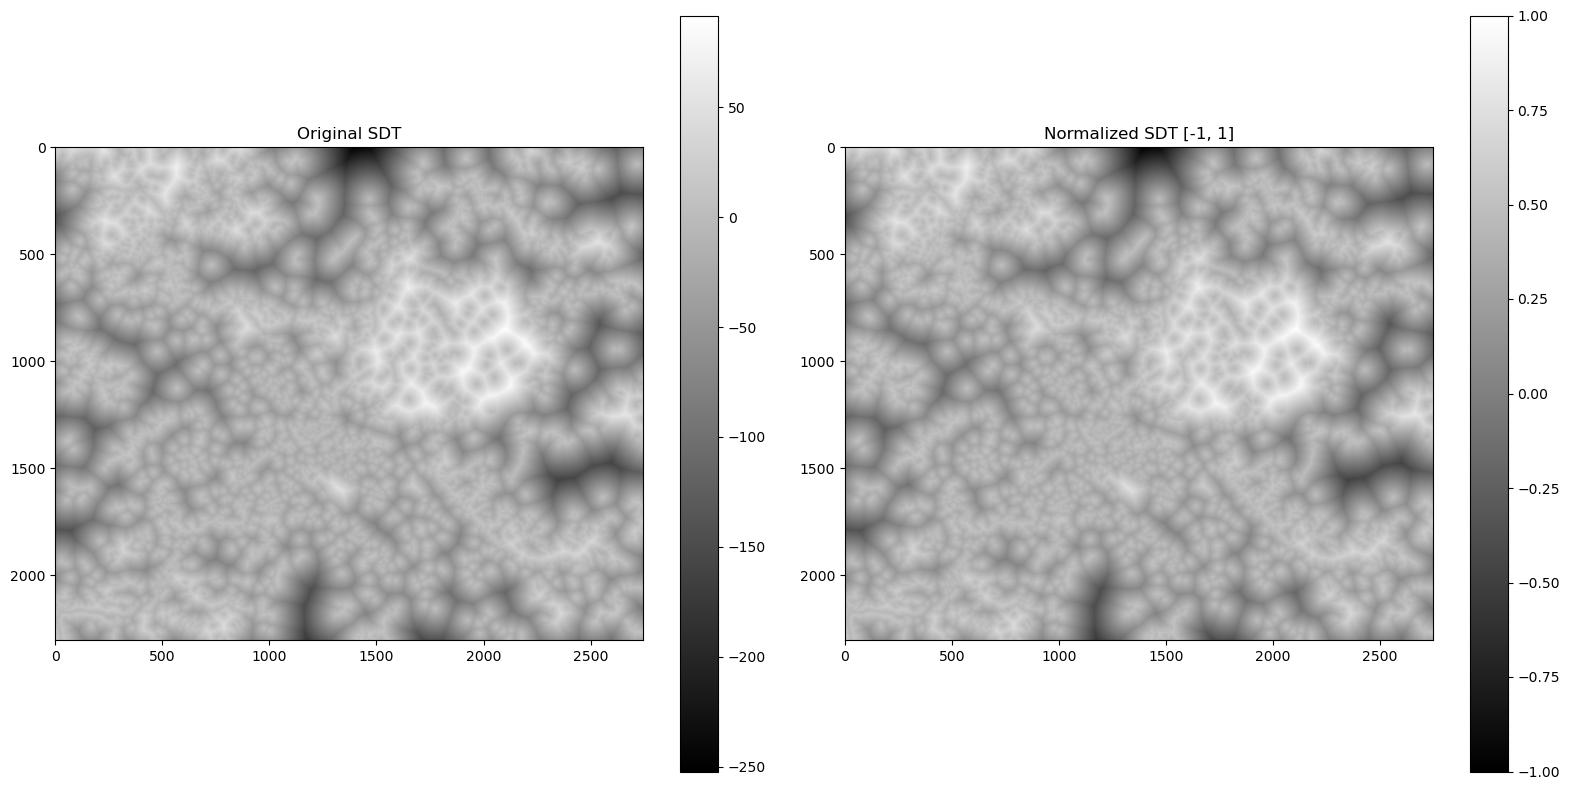

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Original SDT 
im1 = ax1.imshow(sdt_pugs.squeeze(), cmap='gray')
ax1.set_title("Original SDT")
plt.colorbar(im1, ax=ax1)

# Normalized SDT
im2 = ax2.imshow(normalized_sdt_pugs.squeeze(), cmap='gray', vmin=-1, vmax=1)
ax2.set_title("Normalized SDT [-1, 1]")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

In [72]:
normalized_sdt_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 51MB
array([[[ 7.47961542e-01,  7.44396020e-01,  7.40907375e-01, ...,
         -9.81859289e-03, -1.16253894e-02, -1.34958334e-02],
        [ 7.43421187e-01,  7.39796447e-01,  7.36248334e-01, ...,
         -4.28478370e-03, -6.11273870e-03, -8.00491590e-03],
        [ 7.38929261e-01,  7.35243954e-01,  7.31634937e-01, ...,
          1.24217535e-03, -6.07411501e-04, -2.52180187e-03],
        ...,
        [ 5.88554611e-01,  5.82739997e-01,  5.76925382e-01, ...,
          3.32711560e-01,  3.32711560e-01,  3.32711560e-01],
        [ 5.88554611e-01,  5.82739997e-01,  5.76925382e-01, ...,
          3.26896945e-01,  3.26896945e-01,  3.26896945e-01],
        [ 5.88554611e-01,  5.82739997e-01,  5.76925382e-01, ...,
          3.21082330e-01,  3.21082330e-01,  3.21082330e-01]]])
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 15
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

# Calculate NDVI

NDVI min: -0.50303036 NDVI max: 1.0


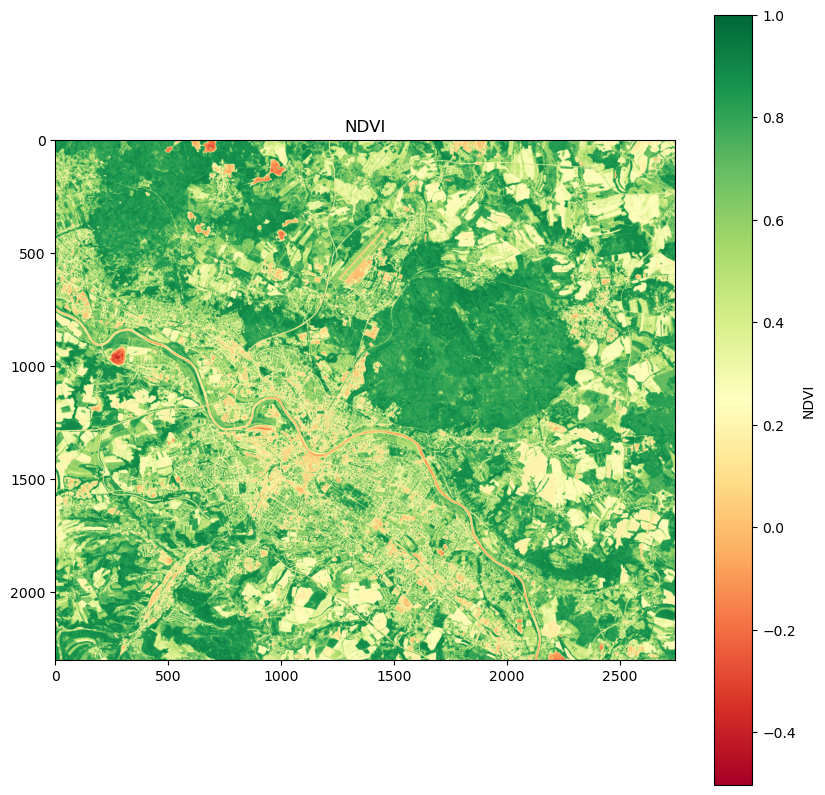

In [73]:
red = data_new_norm_xarray.sel(band=4)
nir = data_new_norm_xarray.sel(band=8)

# Calculate NDVI
ndvi = (nir - red) / (nir + red)
ndvi = ndvi.expand_dims('band').assign_coords(band=[16])

print("NDVI min:", ndvi.min().values, "NDVI max:", ndvi.max().values)

# Plot the NDVI
plt.figure(figsize=(10, 10))
plt.imshow(ndvi.sel(band=16), cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('NDVI')
plt.show()

NDVI min: -0.5155279 NDVI max: 1.0


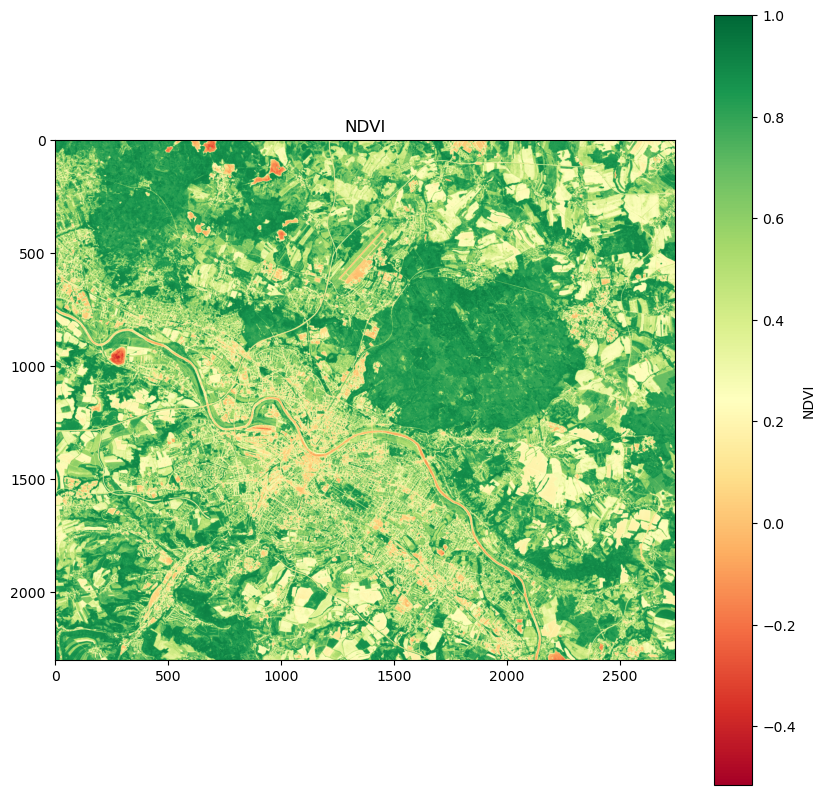

In [74]:
red = processed_sat_img.sel(band=4)
nir = processed_sat_img.sel(band=8)

# Calculate NDVI
ndvi = (nir - red) / (nir + red)
ndvi = ndvi.expand_dims('band').assign_coords(band=[16])

print("NDVI min:", ndvi.min().values, "NDVI max:", ndvi.max().values)

# Plot the NDVI
plt.figure(figsize=(10, 10))
plt.imshow(ndvi.sel(band=16), cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('NDVI')
plt.show()

# Calculate NDWI

NDWI min: -1.0 NDVI max: 0.7390681


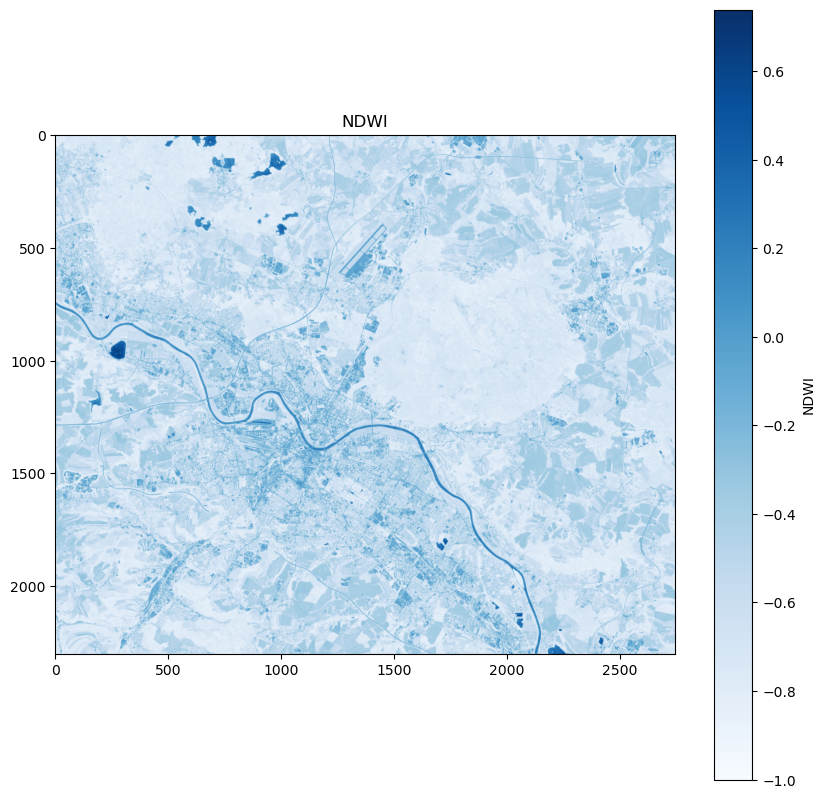

In [75]:
green = processed_sat_img.sel(band=3)

# Calculate NDWI
ndwi = (green - nir) / (green + nir)
ndwi = ndwi.expand_dims('band').assign_coords(band=[17])

print("NDWI min:", ndwi.min().values, "NDVI max:", ndwi.max().values)

# Plot the NDWI
plt.figure(figsize=(10, 10))
plt.imshow(ndwi.sel(band=17), cmap='Blues')
plt.colorbar(label='NDWI')
plt.title('NDWI')
plt.show()

# Calculate NDBI

NDBI min: -0.8294209 NDBI max: 0.6897233


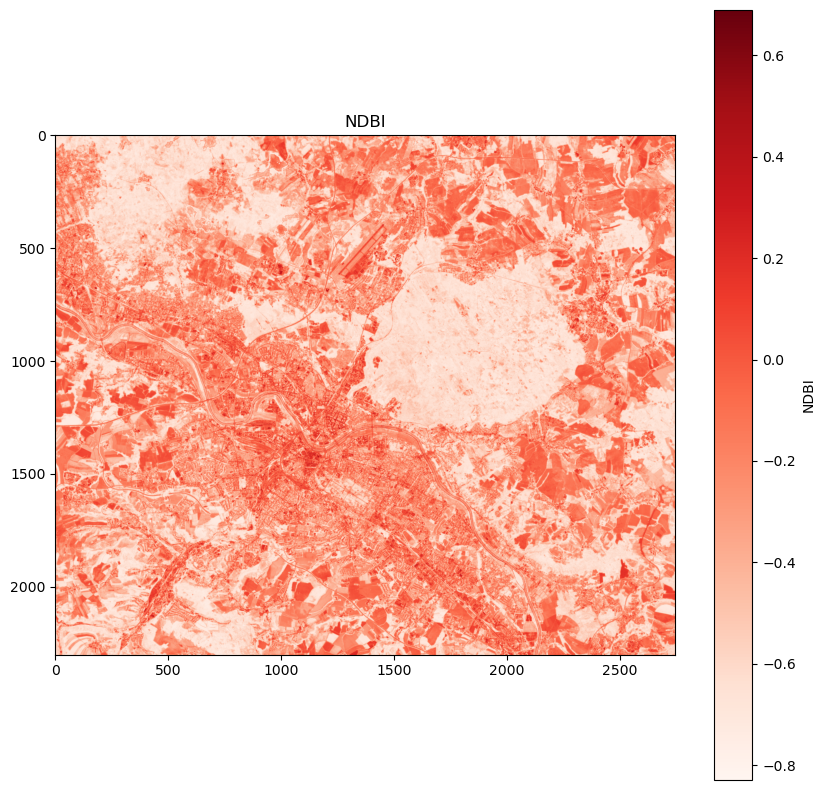

In [76]:
swir = processed_sat_img.sel(band=12)

# Calculate NDBI
ndbi = (swir - nir) / (swir + nir)
ndbi = ndbi.expand_dims('band').assign_coords(band=[18])

print("NDBI min:", ndbi.min().values, "NDBI max:", ndbi.max().values)

# Plot the NDBI
plt.figure(figsize=(10, 10))
plt.imshow(ndbi.sel(band=18), cmap='Reds')
plt.colorbar(label='NDBI')
plt.title('NDBI')
plt.show()

# Stack Sentinel-2 image and indices in one file

In [77]:
stacked_img = xr.concat([processed_sat_img, binary_mask_pugs, normalized_sdt_pugs, ndvi, ndwi, ndbi], dim='band')

In [78]:
output_path = '../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff'

In [79]:
try:
   os.makedirs("../data/processed/sentinel-2")
except FileExistsError:
   # Directory already exists
   pass

stacked_img.rio.to_raster(
    output_path,
    driver="GTiff",
    dtype="float32"
)

# Open the saved file

In [80]:
file_path = '../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff'
data = rioxarray.open_rasterio(file_path, masked=True)

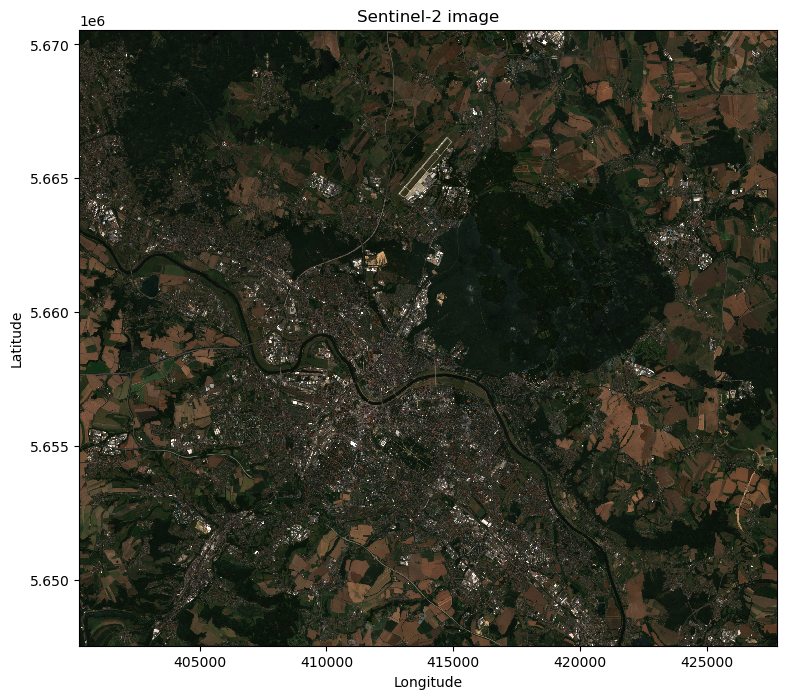

In [81]:
# Plot the raster data
plt.figure(figsize=(9,8))
data.sel(band=[4, 3, 2]).plot.imshow()
plt.title("Sentinel-2 image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

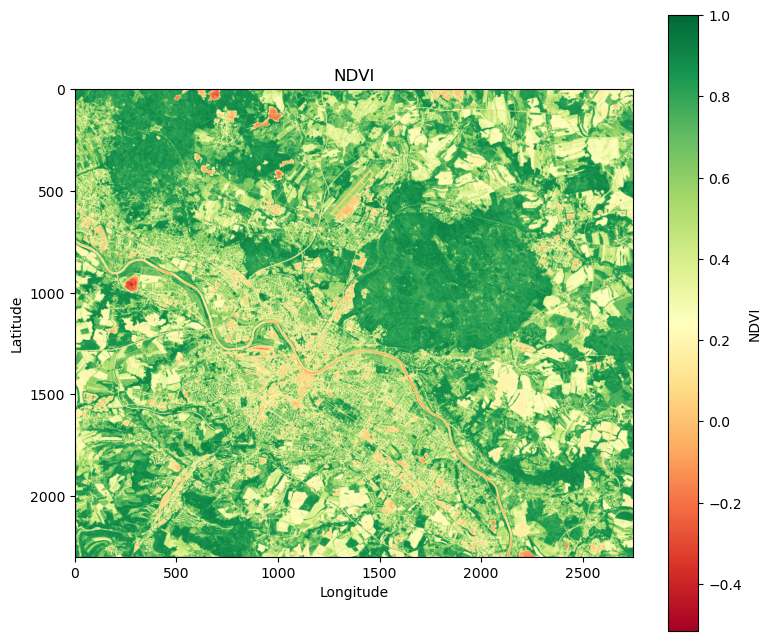

In [82]:
# Plot the raster data
plt.figure(figsize=(9,8))
plt.imshow(data.sel(band=16), cmap='RdYlGn')
plt.title("NDVI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label='NDVI')
plt.show()

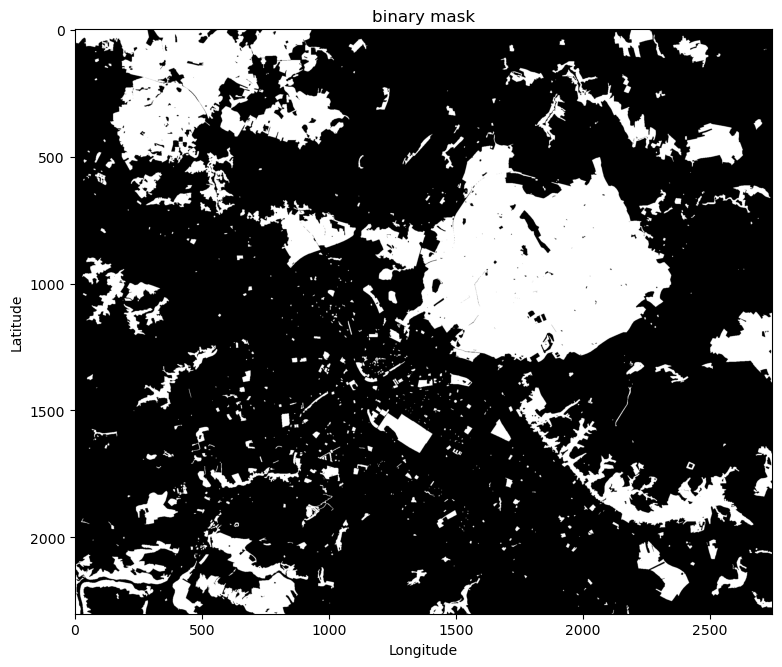

In [83]:
# Plot the raster data
plt.figure(figsize=(9,8))
plt.imshow(data.sel(band=14), cmap='gray')
plt.title("binary mask")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

SDT min: -1.0 , SDT max: 1.0


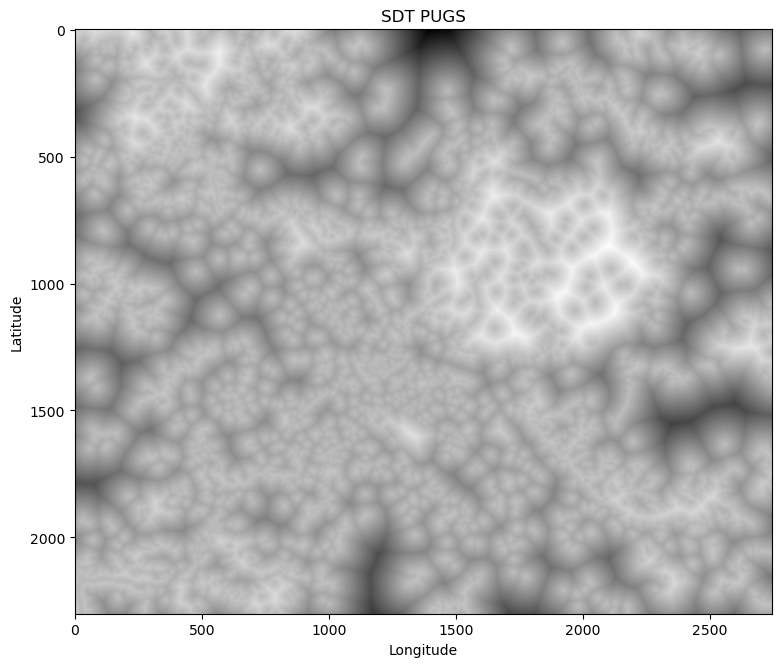

In [84]:
print("SDT min:", data.sel(band=15).min().values, ", SDT max:", data.sel(band=15).max().values)
# Plot the raster data
plt.figure(figsize=(9,8))
plt.imshow(data.sel(band=15), cmap='gray')
plt.title("SDT PUGS")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()